Задание 1

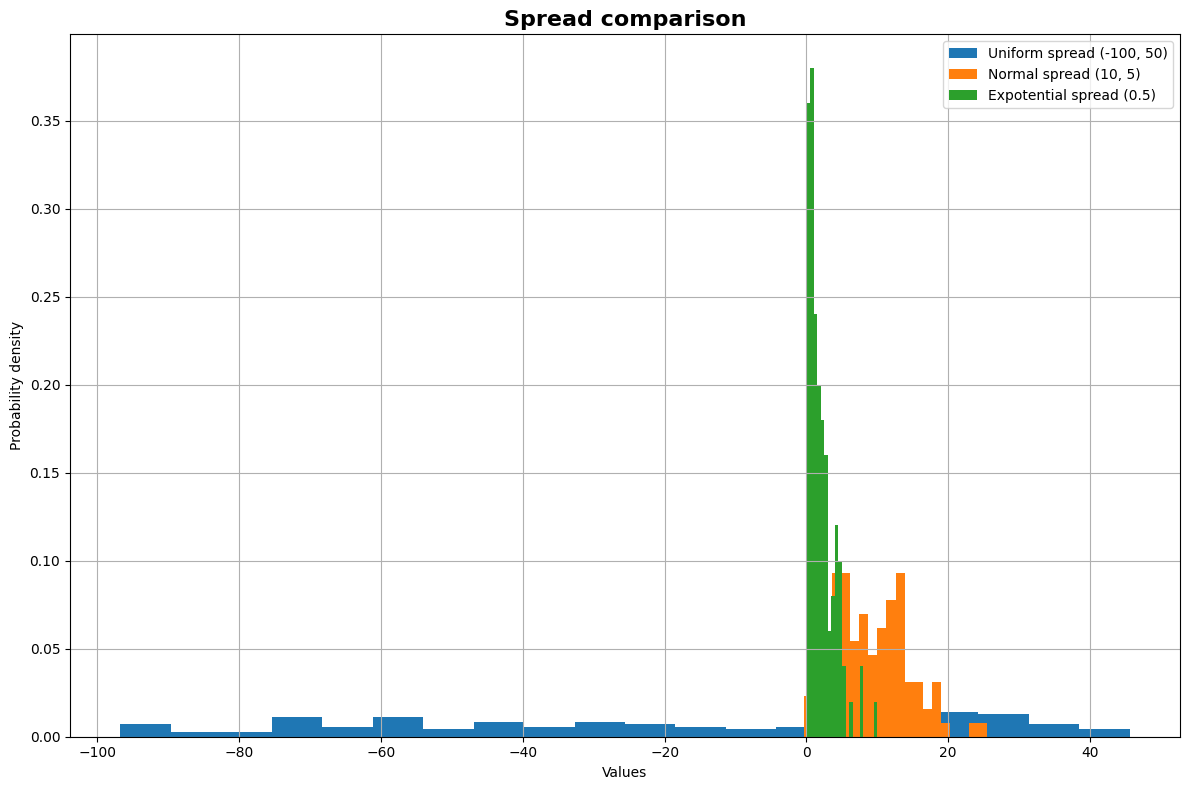

In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(21)

uniform_spread = np.random.uniform(-100, 50, 100)
normal_spread = np.random.normal(10, 5, 100)
expotential_spread = np.random.exponential(1 / 0.5, 100)

plt.figure(figsize=(12, 8))

plt.hist(uniform_spread, bins=20, density=True, label=f'Uniform spread (-100, 50)')
plt.hist(normal_spread, bins=20, density=True, label=f'Normal spread (10, 5)')
plt.hist(expotential_spread, bins=20, density=True, label=f'Expotential spread (0.5)')

plt.title('Spread comparison', fontsize=16, fontweight='bold')
plt.xlabel('Values')
plt.ylabel('Probability density')
plt.legend()

plt.grid()
plt.show()



c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_13872\1220490820.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


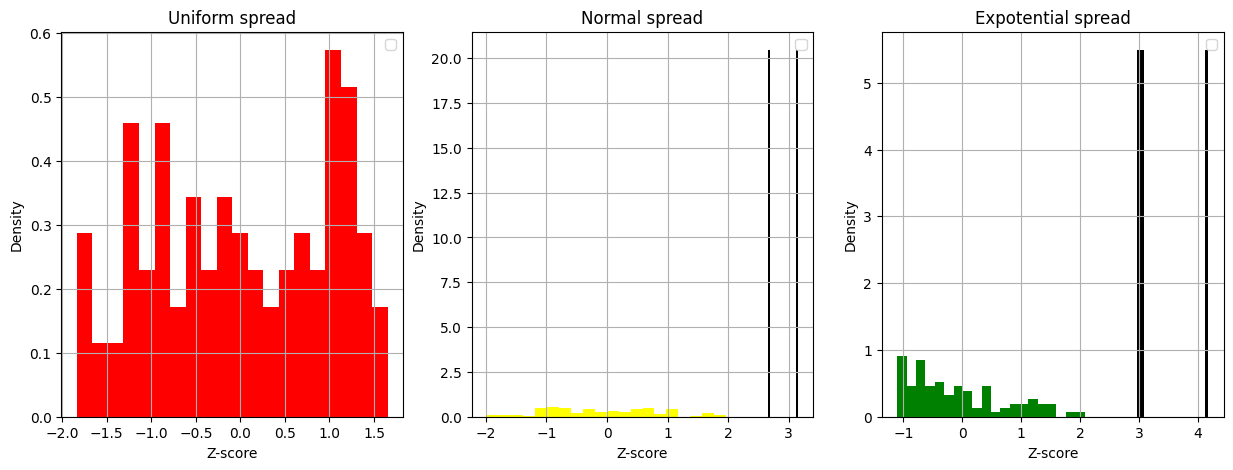

In [22]:
def z_score(list):
    return (list - np.mean(list)) / np.std(list)

z_uniform = z_score(uniform_spread)
z_normal = z_score(normal_spread)
z_exp = z_score(expotential_spread)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
datasets = [z_uniform, z_normal, z_exp]
names = ['Uniform', 'Normal', 'Expotential']
colors = ['red', 'yellow', 'green']

for i, (data, name, color) in enumerate(zip(datasets, names, colors)):
    outliers = np.abs(data) > 2.5
    inliers = ~outliers
    
    axes[i].hist(data[inliers], bins=20, color=color, density=True)
    axes[i].hist(data[outliers], bins=20, color='black', density=True)
    axes[i].set_title(f'{name} spread')
    axes[i].set_xlabel('Z-score')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid()

plt.show()

In [ ]:
print('The amount of elements in a range of diff sigmas:')
for i, (data, name) in enumerate(zip(datasets, names)):
    sigma_1 = np.sum(np.abs(data) <= 1)
    sigma_1_5 = np.sum(np.abs(data) <= 1.5)
    
    print(f'{name}:')
    print(f'Within the limits of 1: {sigma_1}')
    print(f'Within the limits of 1.5: {sigma_1_5}')
    
    print()

print('Manual calculation (uniform and normal spreads):')
x = uniform_spread
y = normal_spread

n = len(x)
mean_x = np.mean(x)
mean_y = np.mean(y)

var_x = np.sum((x - mean_x) ** 2) / (n - 1)
var_y = np.sum((y - mean_y) ** 2) / (n - 1)

cov = np.sum((x - mean_x) * (y - mean_y)) / (n - 1)
corr = cov / (np.sqrt(var_x) * np.sqrt(var_y))

print(f'Variance of a uniform spread: {var_x:.5f}')
print(f'Variance of a normal spread: {var_y:.5f}')
print(f'Covariation: {cov:.5f}')
print(f'Pearson Correlation: {corr:.5f}')

The amount of elements in a range of diff sigmas:
Uniform:
Within the limits of 1: 54
Within the limits of 1.5: 91

Normal:
Within the limits of 1: 67
Within the limits of 1.5: 86

Expotential:
Within the limits of 1: 69
Within the limits of 1.5: 93

Manual calculation (uniform and normal spreads):
Variance of a uniform spread: 1991.24887
Variance of a normal spread: 20.83600
Covariation: -30.51743
Pearson Correlation: -0.14982


In [70]:
print("Calculation using NumPy:")

var_x_np = np.var(x, ddof=1)
var_y_np = np.var(y, ddof=1)

cov_np = np.cov(x, y)[0, 1]
corr_np = np.corrcoef(x, y)[0, 1]

print(f'NumPy Variance of a uniform spread: {var_x_np:.5f}')
print(f'NumPy Variance of a normal spread: {var_y_np:.5f}')
print(f'NumPy Covariation: {cov_np:.5f}')
print(f'NumPy Pearson Correlation: {corr_np:.5f}\n')

print('Results comparison:')
print(f'Variance uniform: {np.isclose(var_x, var_x_np)}')
print(f'Variance normal: {np.isclose(var_y, var_y_np)}')
print(f'Covariation: {np.isclose(cov, cov_np)}')
print(f'Pearson Correlation: {np.isclose(corr, corr_np)}\n')

print('Outliers analysis:')
for i, (data, name) in enumerate(zip(datasets, names)):
    count = np.sum(np.abs(data) >= 2.5)
    percent = count / len(data) * 100
    print(f'{name}: {count}, {percent:.2f}%')

Calculation using NumPy:
NumPy Variance of a uniform spread: 1991.24887
NumPy Variance of a normal spread: 20.83600
NumPy Covariation: -30.51743
NumPy Pearson Correlation: -0.14982

Results comparison:
Variance uniform: True
Variance normal: True
Covariation: True
Pearson Correlation: True

Outliers analysis:
Uniform: 0, 0.00%
Normal: 2, 2.00%
Expotential: 3, 3.00%


In [64]:
def find_subs(arr):
    subs = []
    for i in range(len(arr) - 2):
        if np.sum(arr[i:i + 3]) > 30:
            subs.append(arr[i:i + 3])
    return subs

def find_subs_np(arr):
    windows = np.lib.stride_tricks.sliding_window_view(arr, 3)
    sums = np.sum(windows, axis=1)
    indices = np.where(sums > 30)[0]
    return windows[indices]

np.all(find_subs(uniform_spread) == find_subs_np(uniform_spread))

np.True_

In [26]:
def ema(arr, alpha = 0.2):
    values = np.zeros_like(arr)
    values[0] = arr[0]
    for i in range(1, len(arr)):
        values[i] = alpha * arr[i] + (1 - alpha) * values[i - 1]
    return values

def ema_pd(arr, alpha = 0.2):
    series = pd.Series(arr)
    return series.ewm(alpha=alpha, adjust=False).mean().values

print(f'Manual EMA: {ema(normal_spread)}')
print(f'Pandas EMA: {ema_pd(normal_spread)}')

Manual EMA: [15.16806317 14.83965412 15.42198832 15.1030101  14.42871686 12.48915618
 11.86183618 10.30803449  9.8775974  11.80481785 11.65406151 11.69995201
 10.66602581 13.13563393 10.52522931  9.49331979 10.5405519   9.68185737
  8.95122585  9.66937901 10.48391237 11.0697641   9.99964096 10.75299096
  9.39261777  8.59656197  7.88042448  8.63203649  8.55341585  7.89093083
  8.3442381   7.6519377   7.6166879   7.7814502   7.65727208  7.11970839
  6.44784627  8.25686653  6.53786522  7.52817249  7.21747033  7.06615966
  5.86989371  6.66536542  6.77749086  8.48096179  8.21895733  7.48532675
  6.7871322   8.3865187   9.27711319  9.07251879 10.91687641 10.99978666
 10.50549767 10.92239584  9.63679426  9.80980602  8.7155896   9.54824975
 10.27156748 10.10791848 11.16306362 10.22748221 10.72076574 10.45211334
  9.20682698 10.05337429 11.74107623 14.48734253 13.68228199 13.42662208
 14.45013382 12.51044889 13.52499388 11.15938193  9.77185109  9.59333862
  9.29080415 10.40003533  9.25206685  9

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_13872\3280248021.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


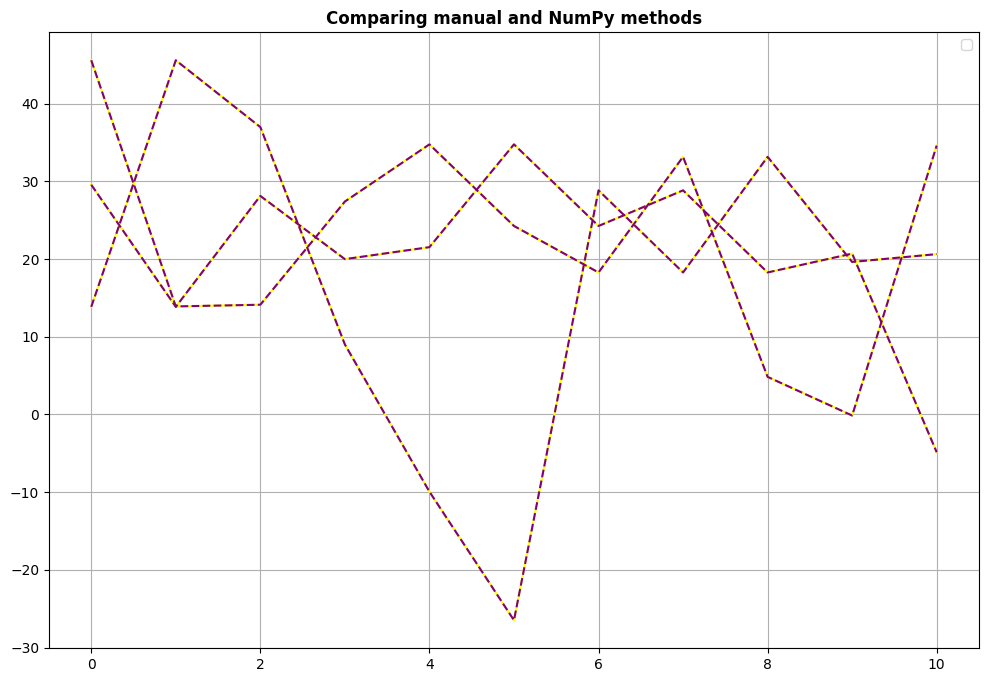

In [27]:
plt.figure(figsize=(12, 8))


plt.plot(find_subs_np(uniform_spread), color = 'yellow')
plt.plot(find_subs(uniform_spread), ls='--', color='purple')
plt.legend()
plt.title('Comparing manual and NumPy methods', fontweight='bold')
plt.grid()
plt.show()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_13872\3725938303.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


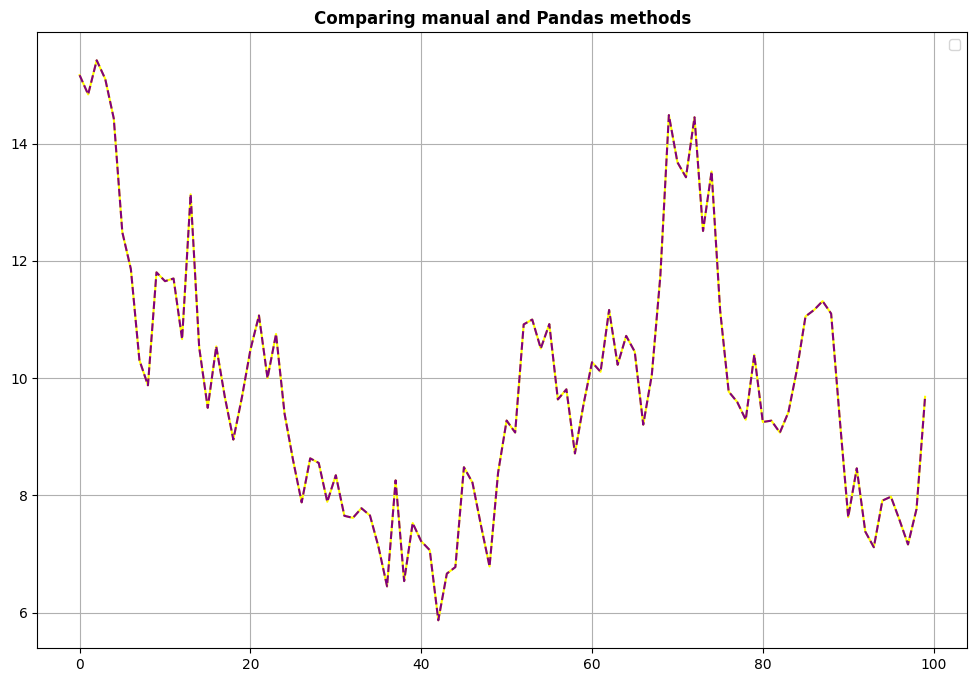

In [28]:
plt.figure(figsize=(12, 8))


plt.plot(ema(normal_spread), color = 'yellow')
plt.plot(ema_pd(normal_spread), ls='--', color='purple')
plt.legend()
plt.title('Comparing manual and Pandas methods', fontweight='bold')
plt.grid()
plt.show()

In [71]:
reshaped = np.reshape(uniform_spread, (10, 10))
for i in range(reshaped.shape[0]):
    min_num = np.min(reshaped[i])
    for j in range(len(reshaped[i])):
        if reshaped[i][j] == min_num:
            reshaped[i][j] = np.nan

Задание 2

In [30]:
from datetime import datetime, timedelta

rows = 500
ids = [_ for _ in range(1, rows + 1)]

ages = np.random.randint(18, 66, rows)

incomes = []
for i in range(rows):
    incomes.append(round(ages[i] * np.random.normal(1.5, 0.2), 2))

end_date = datetime.now()
start_date = end_date - timedelta(days=365*2)
dates = []
for i in range(rows):
    dates.append((start_date + timedelta(days=np.random.randint(0, 365 * 2))).date())

regions = ['Север', 'Юг', 'Центр', 'Восток', 'Запад']
regions_data = np.random.choice(regions, rows, p=[0.2, 0.2, 0.2, 0.2, 0.2])

is_active = np.random.choice([True, False], rows, p = [0.5, 0.5])

df = pd.DataFrame({'user_id': ids, 'age': ages, 'income': incomes, 'subscription_date': dates, 'region': regions_data, 'is_active': is_active})
df

,user_id,age,income,subscription_date,region,is_active
0,1,47,65.75,2024-10-23,Восток,False
1,2,23,37.49,2024-07-17,Центр,True
2,3,64,90.87,2024-01-04,Центр,False
3,4,51,105.07,2025-06-15,Центр,False
4,5,23,33.34,2024-09-16,Центр,False
...,...,...,...,...,...,...
495,496,40,52.89,2025-04-28,Восток,True
496,497,25,37.63,2025-04-09,Юг,False
497,498,27,36.86,2024-11-19,Запад,False
498,499,49,66.41,2024-10-03,Центр,False


In [72]:
df['subscription_date'] = pd.to_datetime(df['subscription_date'])
df['experience_months'] = ((end_date - df['subscription_date']).dt.days / 30).round().astype(int)

In [32]:
groups = ['Низкий', 'Средний', 'Высокий', 'Очень высокий']
quantiles = df['income'].quantile([0.25, 0.5, 0.75])
df['income_group'] = pd.qcut(df['income'], q=[0, 0.25, 0.5, 0.75, 1], labels=groups)
df.head()

,user_id,age,income,subscription_date,region,is_active,experience_months,income_group
0,1,47,65.75,2024-10-23,Восток,False,11,Высокий
1,2,23,37.49,2024-07-17,Центр,True,14,Низкий
2,3,64,90.87,2024-01-04,Центр,False,21,Очень высокий
3,4,51,105.07,2025-06-15,Центр,False,3,Очень высокий
4,5,23,33.34,2024-09-16,Центр,False,12,Низкий


In [33]:
df['loyalty_score'] = (df['income'] / (1 + df['experience_months'])).round(2)
df.head()

,user_id,age,income,subscription_date,region,is_active,experience_months,income_group,loyalty_score
0,1,47,65.75,2024-10-23,Восток,False,11,Высокий,5.48
1,2,23,37.49,2024-07-17,Центр,True,14,Низкий,2.50
2,3,64,90.87,2024-01-04,Центр,False,21,Очень высокий,4.13
3,4,51,105.07,2025-06-15,Центр,False,3,Очень высокий,26.27
4,5,23,33.34,2024-09-16,Центр,False,12,Низкий,2.56


In [74]:
df_region = pd.DataFrame({'region': df['region'], 'income': df['income']}).groupby('region').mean()
df_region

,income
region,
Восток,60.996339
Запад,58.911986
Север,61.639508
Центр,64.647704
Юг,67.133729


In [73]:
df_loyalty = pd.DataFrame({'region': df['region'], 'income_group': df['income_group'], 'loyalty_score': df['loyalty_score']}).groupby(['region', 'income_group']).mean()
df_loyalty

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_13872\4276547944.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_loyalty = pd.DataFrame({'region': df['region'], 'income_group': df['income_group'], 'loyalty_score': df['loyalty_score']}).groupby(['region', 'income_group']).mean()


loyalty_score
region income_group                
Восток Низкий              4.935909
       Средний             4.953000
       Высокий             8.903077
       Очень высокий      11.792222
Запад  Низкий              5.054688
       Средний             7.140833
       Высокий             6.630667
       Очень высокий      10.346316
Север  Низкий              5.917143
       Средний             7.500000
       Высокий             6.588000
       Очень высокий       9.243125
Центр  Низкий              5.098750
       Средний             9.405833
       Высокий            10.099259
       Очень высокий      14.011923
Юг     Низкий              7.012632
       Средний             8.135714
       Высокий             9.568148
       Очень высокий       8.366000

In [36]:
df_highest = df[df['income_group'] == 'Очень высокий']
df_highest = df_highest.sample(frac=0.05)
df_highest

,user_id,age,income,subscription_date,region,is_active,experience_months,income_group,loyalty_score
372,373,57,86.62,2024-09-06,Север,False,12,Очень высокий,6.66
307,308,55,81.83,2024-06-25,Восток,True,15,Очень высокий,5.11
428,429,58,89.61,2024-03-14,Север,True,18,Очень высокий,4.72
300,301,46,80.41,2024-06-24,Север,True,15,Очень высокий,5.03
246,247,47,84.51,2025-08-27,Восток,True,1,Очень высокий,42.26
141,142,49,86.20,2024-07-01,Центр,True,15,Очень высокий,5.39


In [37]:
miss = int(len(df) * 0.05)
miss_indices = np.random.choice(df.index, size=miss, replace=False)
df.loc[miss_indices, 'income'] = np.nan

income_region = df_region['income'].to_dict()
df['income'] = df.apply(
    lambda row: income_region[row['region']] if pd.isna(row['income']) else row['income'], axis=1
)
df.head()

,user_id,age,income,subscription_date,region,is_active,experience_months,income_group,loyalty_score
0,1,47,65.750000,2024-10-23,Восток,False,11,Высокий,5.48
1,2,23,37.490000,2024-07-17,Центр,True,14,Низкий,2.50
2,3,64,90.870000,2024-01-04,Центр,False,21,Очень высокий,4.13
3,4,51,105.070000,2025-06-15,Центр,False,3,Очень высокий,26.27
4,5,23,63.745446,2024-09-16,Центр,False,12,Низкий,2.56


In [38]:
def val_data(df):
    income_val = (df['income'] > 0) & (df['income'].notna())
    age_val = (df['age'] >= 18) & (df['age'] <= 65) & (df['age'].notna())
    df_val = df[income_val & age_val].copy()
    return df_val, len(df) - len(df_val)
df, count = val_data(df)

Задание 3

In [43]:
diamonds = sns.load_dataset("diamonds")
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [44]:
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


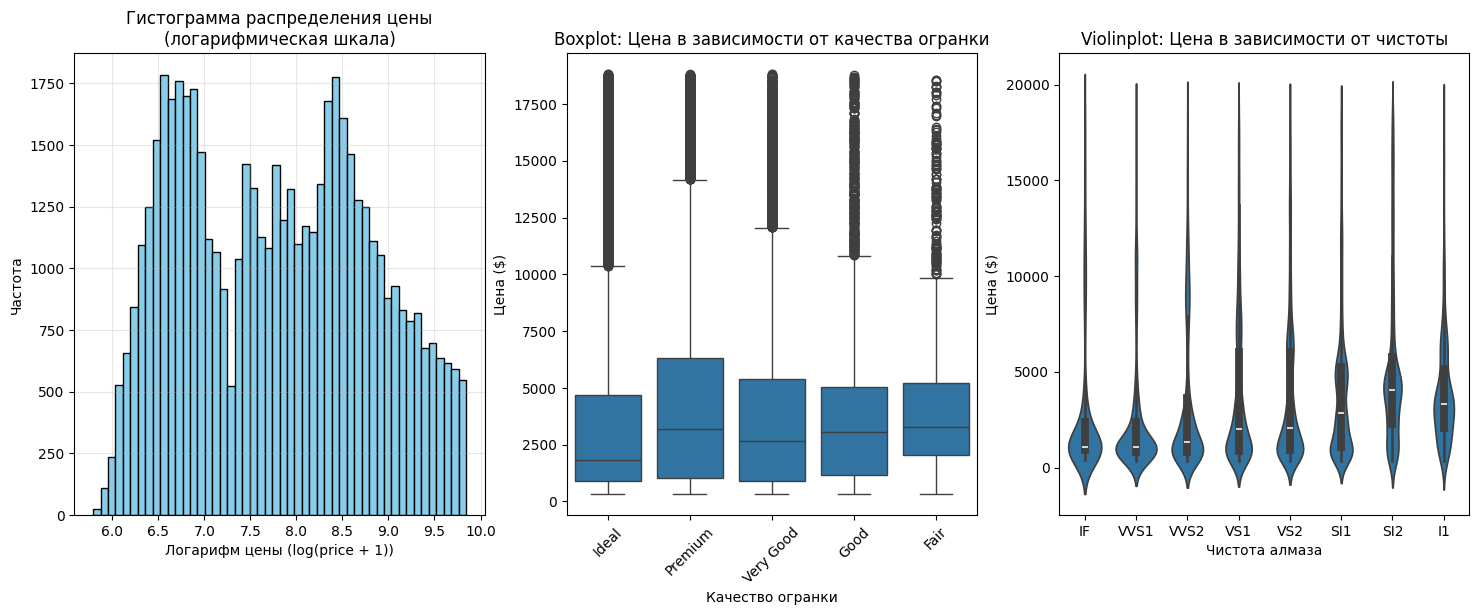

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


axes[0].hist(np.log1p(diamonds['price']), bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Логарифм цены (log(price + 1))')
axes[0].set_ylabel('Частота')
axes[0].set_title('Гистограмма распределения цены\n(логарифмическая шкала)')
axes[0].grid(alpha=0.3)

sns.boxplot(data=diamonds, x='cut', y='price', ax=axes[1])
axes[1].set_title('Boxplot: Цена в зависимости от качества огранки')
axes[1].set_xlabel('Качество огранки')
axes[1].set_ylabel('Цена ($)')
axes[1].tick_params(axis='x', rotation=45)

sns.violinplot(data=diamonds, x='clarity', y='price', ax=axes[2])
axes[2].set_title('Violinplot: Цена в зависимости от чистоты')
axes[2].set_xlabel('Чистота алмаза')
axes[2].set_ylabel('Цена ($)')

plt.show()

In [46]:
print("Анализ выбросов по категориям чистоты (clarity):")
clarity_categories = diamonds['clarity'].unique()
for clarity in clarity_categories:
    subset = diamonds[diamonds['clarity'] == clarity]['price']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = subset[(subset < lower_bound) | (subset > upper_bound)]
    print(f"{clarity}: {len(outliers)} выбросов (верхняя граница: {upper_bound:.0f}$)")

Анализ выбросов по категориям чистоты (clarity):
SI2: 1087 выбросов (верхняя граница: 11047$)
SI1: 888 выбросов (верхняя граница: 11492$)
VS1: 330 выбросов (верхняя граница: 13744$)
VS2: 564 выбросов (верхняя граница: 13709$)
VVS2: 859 выбросов (верхняя граница: 7904$)
VVS1: 485 выбросов (верхняя граница: 4724$)
I1: 35 выбросов (верхняя граница: 9782$)
IF: 278 выбросов (верхняя граница: 4629$)


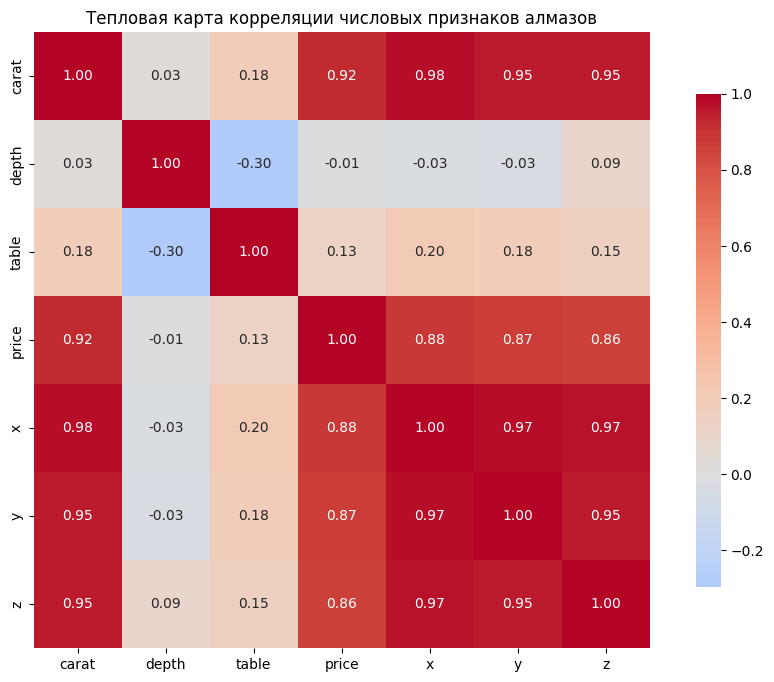

In [50]:
numeric_cols = diamonds.select_dtypes(include=[np.number]).columns
correlation_matrix = diamonds[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Тепловая карта корреляции числовых признаков алмазов')
plt.show()

<Figure size 1200x800 with 0 Axes>

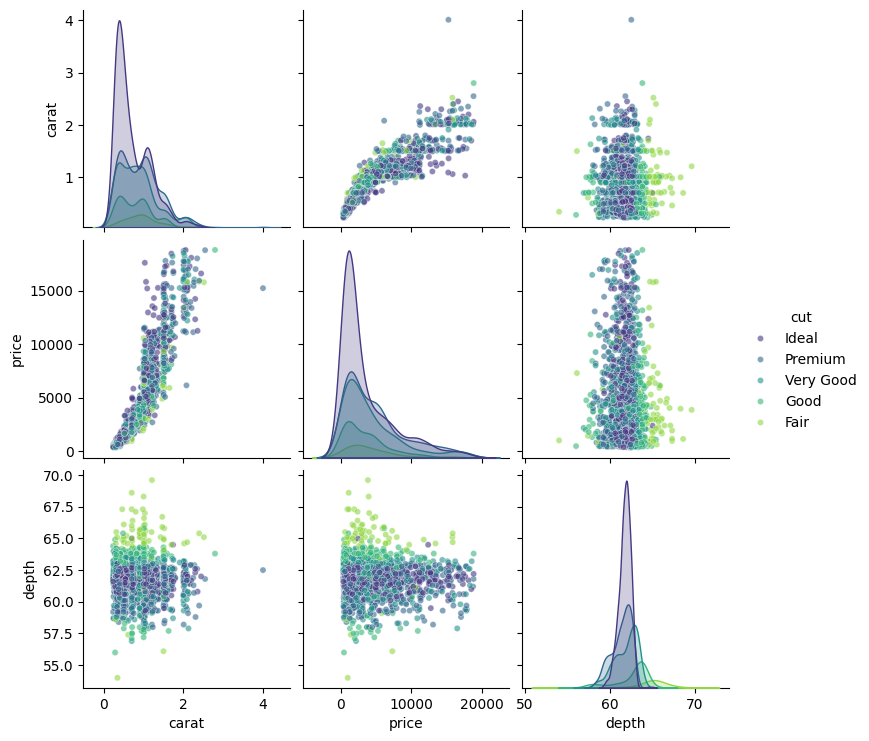

In [51]:
plt.figure(figsize=(12, 8))
sns.pairplot(diamonds.sample(2000),  # Берем выборку для лучшей визуализации
             vars=['carat', 'price', 'depth'],
             hue='cut',
             palette='viridis',
             plot_kws={'alpha': 0.6, 's': 20},
             diag_kind='kde')
plt.show()

In [54]:
pivot_table = diamonds.pivot_table(
    values='price',
    index='cut',
    columns='color',
    aggfunc='mean',
    fill_value=0
)
print("Сводная таблица: Средняя цена в зависимости от cut и color")
print("=" * 60)
print(pivot_table.round(2))
print("=" * 60)

Сводная таблица: Средняя цена в зависимости от cut и color
color            D        E        F        G        H        I        J
cut                                                                     
Ideal      2629.09  2597.55  3374.94  3720.71  3889.33  4451.97  4918.19
Premium    3631.29  3538.91  4324.89  4500.74  5216.71  5946.18  6294.59
Very Good  3470.47  3214.65  3778.82  3872.75  4535.39  5255.88  5103.51
Good       3405.38  3423.64  3495.75  4123.48  4276.25  5078.53  4574.17
Fair       4291.06  3682.31  3827.00  4239.25  5135.68  4685.45  4975.66


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_13872\3618514712.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = diamonds.pivot_table(


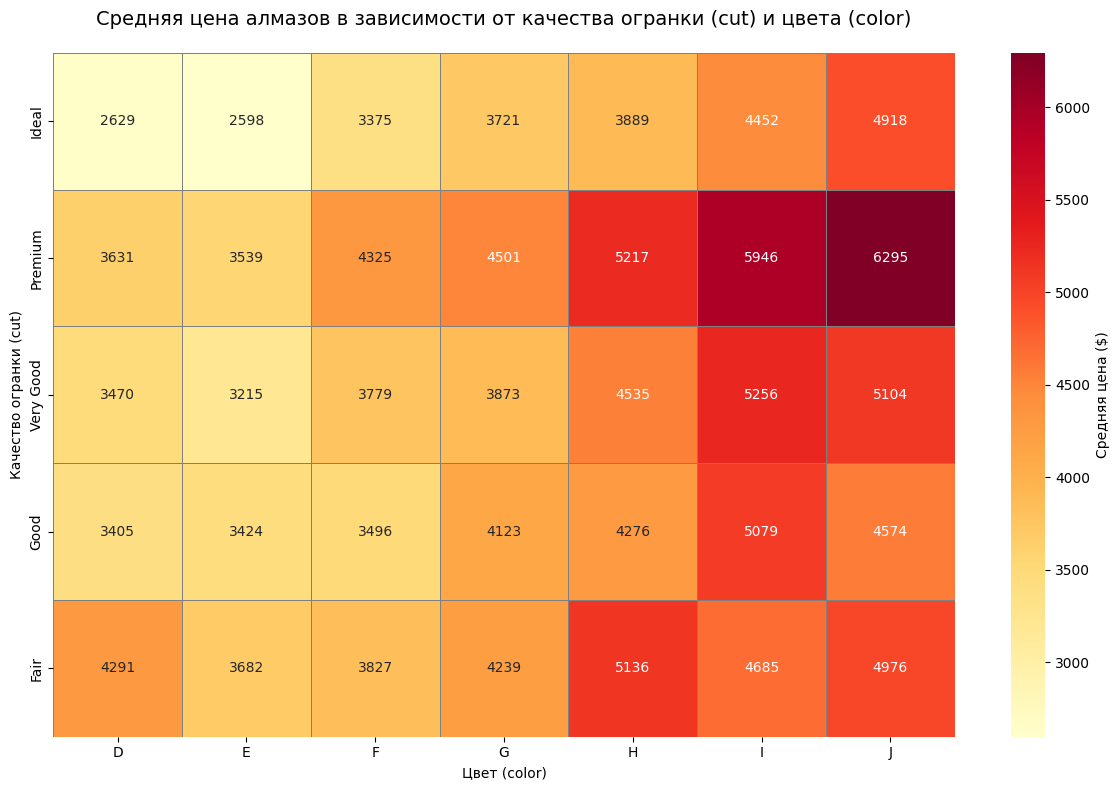

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd', 
            cbar_kws={'label': 'Средняя цена ($)'},
            linewidths=0.5,
            linecolor='gray')
plt.title('Средняя цена алмазов в зависимости от качества огранки (cut) и цвета (color)',
          fontsize=14, pad=20)
plt.xlabel('Цвет (color)')
plt.ylabel('Качество огранки (cut)')
plt.show()

In [56]:
def sliding_window(x, w, step):
    slides = []
    for i in range(0, len(x) - w + 1, step):
        slides.append(x[i:i + w])
    return slides

In [ ]:
window = 3
step_s = 1
x1 = np.array([8, 1, 4, 5, -2, 5, 9, 0])
A1 = np.array([[8, 1, 4],
[1, 4, 5],
[4, 5, -2],
[5, -2, 5],
[-2, 5, 9],
[5, 9, 0]])
print(np.array_equal(sliding_window(x1, w=window,
step=step_s),A1))
window = 2
step_s = 4
x2 = np.array([8, 3, 4, 1, -6, 5, 9, 2, 10, 11, -14, 0])
A2 = np.array([[8, 3],
[-6, 5],
[10, 11]])
print(np.array_equal(sliding_window(x2, w=window,
step=step_s),A2))


True
True
